In [1]:
import sys
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import logging
from patsy import bs
import itertools

from monotonic_risk_score import (
    prepare_long_for_target,
    estimate_passage_metrics_per_target,
    compute_coverage_levels,
    compute_score_low_high,
    plot_heatmap_k,
    plot_heatmap_agg,
    plot_pareto_low_high,
    evaluate_monotonic_risk
)

# Setup logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


In [2]:
# Configuration
base_path = Path('/home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction/GNN/bdiff/firepoint/2x2/test/occurence_default/all/full_all_departement_0_None_node')
parent_dir_name = 'full_all_departement_0_None_node'

scale = 10
horizon = 0

models = [
    #'DilatedCNN_search_full_10_0_all_one_',
    'GRU_search_full_10_0_all_one_',
    #'LSTM_search_full_10_0_all_one_',
    #'NetMLP_search_full_10_0_all_one_',
    #'NetMLP_search_full_0_0_all_one_',
    #'graphCastGRU_search_full_10_0_all_one_',
    #'graphCastGRUWithAttentionGAT_search_full_10_0_all_one_'
]

losses = [
    'classification_wkloss',
    'classification_bceloss',
    'classification_weightedcrossentropy',
    'regression_pdegpd',
    'classification_flwk',
    'classification_flwki-id{departement}',
]

targets = [
   'nbsinister-kmeans-5-Class-Dept',
]

all_dir = list(itertools.product(models, losses, targets))

def find_directories(base_path):
    matches = []
    if not base_path.exists():
        print(f"Base path does not exist: {base_path}")
        return []

    for (model, loss, target) in all_dir:
        # Construct exact directory name: model + target + '_' + loss
        # Note: model strings already include the trailing underscore
        dir_name = f"{model}{target}_{loss}"
        full_path = base_path / dir_name
        
        if full_path.exists() and full_path.is_dir():
            matches.append((full_path, model, loss, target))
        # else:
        #     print(f"Directory not found: {dir_name}")
            
    return matches

directories = find_directories(base_path)
print(f"Found {len(directories)} directories matching configuration.")

Found 6 directories matching configuration.


In [3]:
data_frames = {}
gt_dfs = {}
target_cols = {}

print(f"Found {len(directories)} directories.")

for d, model, loss, target in directories:
    
    if target is None:
        # Try to guess target or skip
        continue

    # Load pickle
    # Search for pickle in H0 subdirectory or current directory
    pkl_files = []
    h0_path = os.path.join(d, "H0")
    if os.path.exists(h0_path):
        pkl_files.extend([os.path.join(h0_path, f) for f in os.listdir(h0_path) if f.endswith(".pkl")])
    
    if not pkl_files:
        pkl_files.extend([os.path.join(d, f) for f in os.listdir(d) if f.endswith(".pkl")])
        
    if not pkl_files:
        # print(f"Skipping {d}: no pickle found")
        continue
        
    # Use the first pickle found (assuming one relevant pickle per dir)
    file_path = pkl_files[0]
        
    try:
        with open(file_path, "rb") as f:
            res = pd.read_pickle(f)
    except Exception as e:
        print(f"Error loading {d}: {e}")
        continue

    # Ensure required columns
    if "date" not in res.columns or "graph_id" not in res.columns:
        print(f"Skipping {d}: missing date or graph_id")
        continue
        
    # Identify prediction column
    # Usually 'prediction' or the target name itself if it's a baseline, 
    # but for models it's often 'prediction' or 'output'.
    # Let's check for 'prediction'
    pred_col = f"prediction_{target}_0"
    if pred_col not in res.columns:
        # Check if target column exists and use it (e.g. for perfect baseline)
        if target in res.columns:
            pred_col = target
        else:
            print(f"Skipping {d}: no prediction column")
            continue

    # Prepare dataframe for risk_all
    df = res[["date", "graph_id", target]].copy()
    df["risk_score"] = res[pred_col]
    df[pred_col] = res[pred_col]
    df["config"] = f"{model}{loss}" # Use directory name as config/model name
    
    if 'nbsinister' in target:
        df['nbsinister'] = res['nbsinister']
    else:
        df['burnedareaRoot'] = res['burnedareaRoot']
    
    data_frames[f"{model}{loss}"] = df
    
    # Store Ground Truth if not already stored for this target
    # OR if it is stored but missing the baseline column, and the current one has it.
    
    # Determine baseline column name (logic from monotonic_risk_score.py)
    baseline_col = f"{target}"

    has_baseline = baseline_col in res.columns
    
    cols_to_keep = ["date", "graph_id"]
    if has_baseline:
        cols_to_keep.append(baseline_col)
        
    gt_df = res[["date", "graph_id", target]].copy()
    
    gt_df[pred_col] = gt_df[target]
    gt_df = res[cols_to_keep].copy()
    gt_dfs[target] = gt_df
    target_cols[target] = target
    
    if has_baseline:
        print(f"Loaded GT for {target} from {d} (with baseline)")
    else:
        print(f"Loaded GT for {target} from {d} (NO baseline)")
        
print(f"Loaded {len(data_frames)} configurations.")

if not data_frames:
    print("No data loaded. Please check paths and pickle files.")
else:
    risk_all = pd.concat(data_frames.values(), ignore_index=True)
    print("risk_all shape:", risk_all.shape)


Found 6 directories.
Loaded GT for nbsinister-kmeans-5-Class-Dept from /home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction/GNN/bdiff/firepoint/2x2/test/occurence_default/all/full_all_departement_0_None_node/GRU_search_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_wkloss (with baseline)
Loaded GT for nbsinister-kmeans-5-Class-Dept from /home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction/GNN/bdiff/firepoint/2x2/test/occurence_default/all/full_all_departement_0_None_node/GRU_search_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_bceloss (with baseline)
Loaded GT for nbsinister-kmeans-5-Class-Dept from /home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction/GNN/bdiff/firepoint/2x2/test/occurence_default/all/full_all_departement_0_None_node/GRU_search_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_weightedcrossentropy (with baseline)
Loaded GT for nbsinister-kmeans-5-Class-Dept from /home/caron/Bureau/ST-GNN-for-wildi

In [4]:
gt_dfs['nbsinister-kmeans-5-Class-Dept']

,date,graph_id,nbsinister-kmeans-5-Class-Dept
0,2029,0.0,0
1,2030,0.0,0
2,2031,0.0,0
3,2032,0.0,0
4,2033,0.0,0
...,...,...,...
33483,2388,93.0,0
33484,2389,93.0,0
33485,2390,93.0,0
33486,2391,93.0,0



--- Starting Evaluation ---
Preparing data for nbsinister-kmeans-5-Class-Dept...
Computing metrics for nbsinister-kmeans-5-Class-Dept...
Estimate metrics for config: GRU_search_full_10_0_all_one_classification_bceloss
Computing passage metrics for config with 33488 data points...
Fitting spline mu with df_spline = 5
Genération des métriques de passage...
Estimate metrics for config: GRU_search_full_10_0_all_one_classification_flwk
Computing passage metrics for config with 33488 data points...
Fitting spline mu with df_spline = 5
Genération des métriques de passage...
Estimate metrics for config: GRU_search_full_10_0_all_one_classification_flwki-id{departement}
Computing passage metrics for config with 33488 data points...
Fitting spline mu with df_spline = 5
Genération des métriques de passage...
Estimate metrics for config: GRU_search_full_10_0_all_one_classification_weightedcrossentropy
Computing passage metrics for config with 33488 data points...
Fitting spline mu with df_spline =

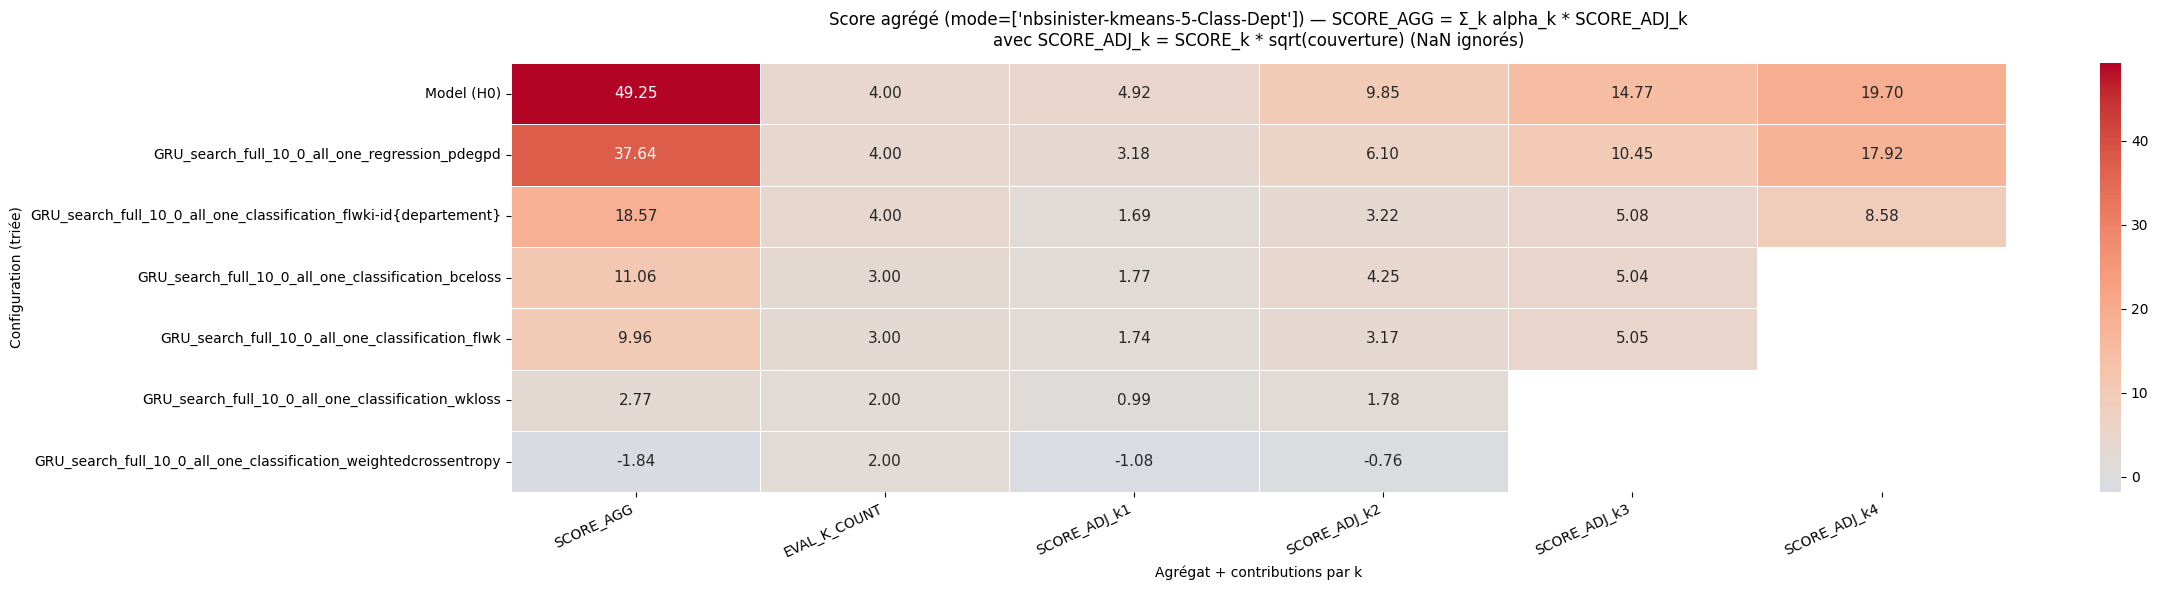

Best config (agg): Model (H0)
Computing coverage...
Computing scores LOW/HIGH...
Plotting Pareto...


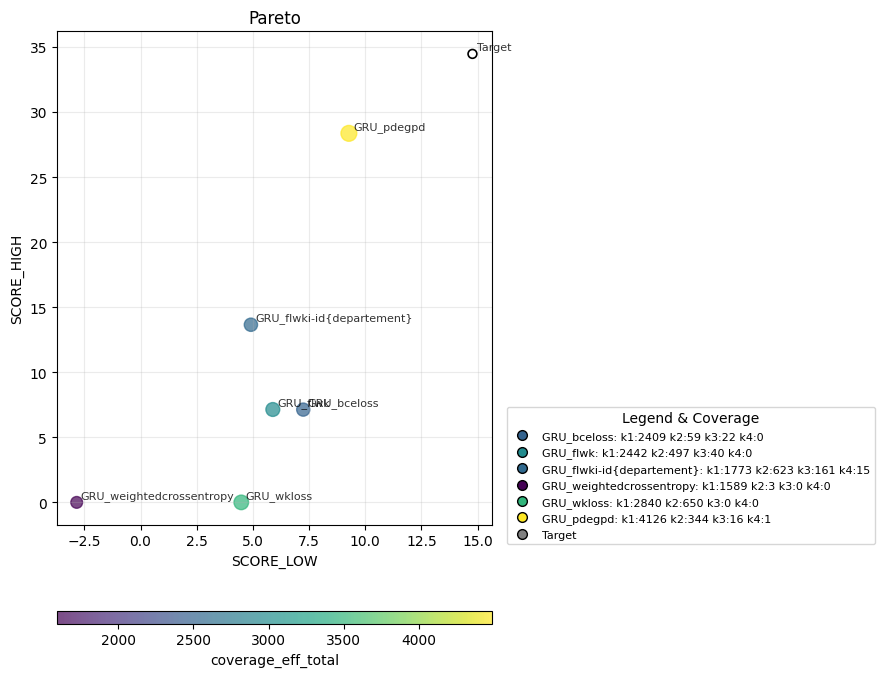


Evaluation Complete.


In [5]:
print("\n--- Starting Evaluation ---")

df_long_by_target = {}
# Iterate over gt_dfs which we populated during loading
for target_name, gt_df in gt_dfs.items():
    print(f"Preparing data for {target_name}...")
    # y_col is the target name in our loading logic
    y_col = target_name
    
    try:
        df_long = prepare_long_for_target(
            risk_all, gt_df, y_col,
            add_dfe_score_as_config=False,
            dfe_df=None,
            dfe_config_name=""
        )
        df_long_by_target[target_name] = df_long
    except Exception as e:
        print(f"Error preparing {target_name}: {e}")

all_metrics = {}
for t, df_long in df_long_by_target.items():
    print(f"Computing metrics for {t}...")
    all_metrics[t] = estimate_passage_metrics_per_target(df_long, df_spline=5, min_n=50)

# Standardise by sigma(Y) for each target (only deltas/neg_mass/min)
Y_std = {t: df_long_by_target[t]["Y"].std() for t in df_long_by_target}

for t in all_metrics:
    sigma = Y_std[t]
    if sigma == 0 or np.isnan(sigma):
        print(f"Warning: Sigma is 0 or NaN for {t}, skipping standardization")
        continue
        
    for k in [1,2,3,4]:
        for metric in [f"avg_delta_{k}", f"min_delta_{k}", f"neg_mass_{k}"]:
            if metric in all_metrics[t].columns:
                all_metrics[t][f"{metric}_STD"] = all_metrics[t][metric] / sigma

# 4 plots: +1, +2, +3, +4
# We use list(all_metrics.keys()) as targets/mode
targets_list = list(all_metrics.keys())

for k in [1, 2, 3, 4]:
    try:
        print(f"Plotting heatmap k={k}...")
        #rank_k, view_k = plot_heatmap_k(all_metrics, k=k, targets=targets_list, top_n=30, fig_w=30, annot_font=11, fmt=".2f")
        #plt.show()
        #if not rank_k.empty:
        #    print(f"Best config (+{k}): {rank_k.index[0]}")
    except Exception as e:
        print(f"Error plotting k={k}: {e}")

try:
    print("Plotting aggregated heatmap...")
    rank_agg, view_agg = plot_heatmap_agg(all_metrics, mode=targets_list, top_n=30, ks=(1,2,3,4))
    plt.show()
    if not rank_agg.empty:
        print(f"Best config (agg): {rank_agg.index[0]}")
except Exception as e:
    print(f"Error plotting agg: {e}")


# 1) Coverage 0..4 par config
# We need a representative df_long for coverage. 
# The user snippet used `df_long` which was the last one in the loop.
# Ideally coverage should be computed on risk_all directly or one of the targets?
# compute_coverage_levels takes df_long which has 'score' and 'config'.
# risk_all has 'score' and 'config'.
print("Computing coverage...")
coverage = compute_coverage_levels(risk_all, score_col="risk_score", config_col="config")

# 2) Scores LOW/HIGH (ici LOW=k1+k2, HIGH=k3+k4)
print("Computing scores LOW/HIGH...")
scores_lh = compute_score_low_high(all_metrics=all_metrics, mode=targets_list,
                                  low_ks=(1,2), high_ks=(3,4),
                                  use_adj=False)

# 3) Plot Pareto + afficher coverage via taille
if "coverage_eff_k1" in coverage.columns:
    coverage["coverage_eff_total"] = (
        coverage.get("coverage_eff_k1", 0) + coverage.get("coverage_eff_k2", 0) +
        coverage.get("coverage_eff_k3", 0) + coverage.get("coverage_eff_k4", 0)
    )

    print("Plotting Pareto...")
    try:
        pareto = plot_pareto_low_high(
            scores_lh,
            coverage_df=coverage,
            size_by="coverage_eff_total",
            color_by="coverage_eff_total",
            show_coverage_text="k",
            title="Pareto"
        )
        plt.show()
    except Exception as e:
        print(f"Error plotting Pareto: {e}")
else:
    print("Coverage columns missing, skipping Pareto plot.")

print("\nEvaluation Complete.")


In [8]:
def plot_spline_effect_for_target_multi(
    df_long,
    cfg_names,
    target_label,
    df_spline=5,
    grid=None,
    ax=None,
    show=True,
    legend=True,
):
    """
    Trace plusieurs courbes d'effet spline (score -> E[Y]) sur une même target,
    une courbe par config.

    Parameters
    ----------
    df_long : pd.DataFrame
        Doit contenir: config, score, Y, num_zone, date.
    cfg_names : str | list[str]
        Une config (str) ou une liste de configs.
    target_label : str
        Label affiché (ex: "Taux", "Conso", etc.).
    df_spline : int
        df pour bs().
    grid : array-like | None
        Grille de score. Par défaut linspace(0,4,81).
    ax : matplotlib axis | None
        Pour dessiner sur un axe existant.
    show : bool
        Si True, plt.show() si ax est None.
    legend : bool
        Si True, affiche la légende.

    Returns
    -------
    dict[str, statsmodels.regression.linear_model.RegressionResultsWrapper]
        fits par config.
    """
    if isinstance(cfg_names, str):
        cfg_names = [cfg_names]

    if grid is None:
        grid = np.linspace(0, 4, 81)
    else:
        grid = np.asarray(grid)

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))
        created_fig = True

    fits = {}

    for cfg_name in cfg_names:
        d = (
            df_long[df_long["config"] == cfg_name]
            .dropna(subset=["score", "Y"])
            .copy()
        )

        if d.empty:
            print(f"[{target_label}] Pas de données pour config={cfg_name}")
            continue

        # Sécurité : scores dans [0,4]
        d["score"] = d["score"].clip(0, 4)

        formula = (
            f"Y ~ bs(score, df={df_spline}, degree=3, include_intercept=False,"
            f" lower_bound=0, upper_bound=4) + C(graph_id) + C(date)"
        )
        fit = smf.ols(formula, data=d).fit(cov_type="HC1")
        fits[cfg_name] = fit

        # Gabarit pour moyenner sur la distribution (num_zone, date) de la config
        template = d[["score", "graph_id", "date", "Y"]].copy()

        preds = []
        for s in grid:
            tmp = template.copy()
            tmp["score"] = float(s)
            v = fit.predict(tmp).mean()
            v = max(0, v)
            preds.append(v)
        preds = np.asarray(preds)

        ax.plot(grid, preds, label=str(cfg_name))

    ax.set_xlim(0, 4)
    ax.set_xlabel("score (0–4)")
    ax.set_ylabel(f"E[{target_label}] estimée")
    ax.set_title(f"{target_label} — Spline Effect (df={df_spline})")
    ax.grid(True, alpha=0.2)

    if legend and len(fits) > 0:
        ax.legend(title="config")

    if created_fig:
        plt.tight_layout()
        if show:
            plt.show()


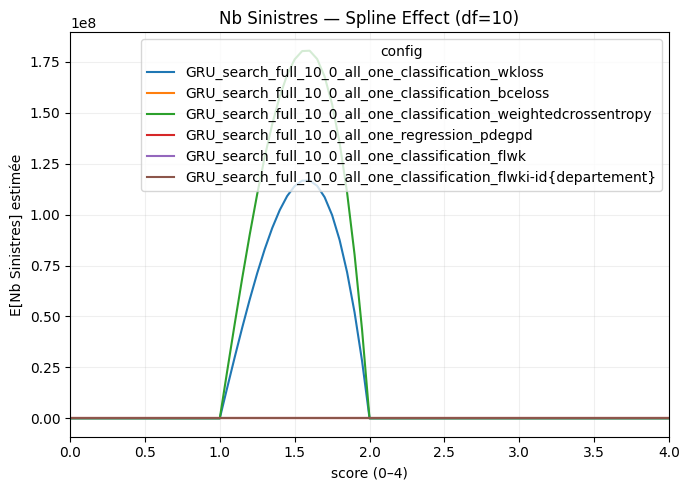

In [10]:
plot_spline_effect_for_target_multi(
    df_long=df_long_by_target['nbsinister-kmeans-5-Class-Dept'],
    cfg_names=list(data_frames.keys()),
    target_label="Nb Sinistres",
    df_spline=10,
)